# Phase 11 — Ce que mesurent les instruments, et ce qu'ils ne pouvaient pas voir

**Question de soutenance :** tous les résultats du projet disent « non établi ».
Est-ce parce qu'il n'y a rien à voir, ou parce que le protocole ne pouvait
rien voir ?

Ce notebook n'ajoute aucune stratégie. Il ajoute des **instruments de mesure**
et les applique aux séries déjà publiées : `reality_check_series.parquet`,
`dashboard_equity.parquet`, `reality_check_results.json`. La distinction qu'il
établit est celle entre une absence d'effet et une absence de puissance.

Les deux résultats centraux :

1. l'écart de Sharpe **détectable** par le protocole est plusieurs fois
   supérieur à l'écart **observé** — la conclusion négative était fixée par
   la taille d'échantillon avant tout entraînement ;
2. la performance en apprentissage **anti-prédit** la performance hors
   échantillon, avec une pente proche de $-1$.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "data" / "gold").exists():
    ROOT = ROOT.parent
GOLD = ROOT / "data" / "gold"
BRONZE = ROOT / "data" / "bronze"

def load_json(name):
    return json.loads((GOLD / name).read_text(encoding="utf-8"))

snapshot = load_json("snapshot_manifest.json")
assert snapshot["git_dirty"] is False, "Le snapshot source doit être propre."

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5.5),
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    "equal_weight": "#94a3b8",
    "min_variance_lw": "#14b8a6",
    "max_sharpe": "#2563eb",
    "regime_conditional": "#f59e0b",
    "dcc_garch": "#0f766e",
    "rf_signal": "#8b5cf6",
    "xgb_signal": "#ef4444",
    "rf_signal_tuned": "#8b5cf6",
    "xgb_signal_tuned": "#ef4444",
}

display(Markdown(
    f"**Snapshot canonique :** `{snapshot['git_commit'][:12]}`  "
    f"— généré le `{snapshot['generated_at_utc']}` — arbre source propre."
))

# Palette validée (contraste et daltonisme vérifiés par outil, pas à l'œil).
# Les trois premiers créneaux catégoriels passent tous les seuils sur fond clair.
SERIE_1 = "#2a78d6"   # bleu   — la quantité observée
SERIE_2 = "#eb6834"   # orange — le seuil de détection
CRITIQUE = "#d03b3b"  # rouge statut — réservé à l'état « non détectable »
ENCRE = "#0b0b0b"
ENCRE_2 = "#52514e"
ATTENUE = "#898781"
GRILLE = "#e1e0d9"
FOND = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": FOND,
    "axes.facecolor": FOND,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": ENCRE_2,
    "axes.titlecolor": ENCRE,
    "xtick.color": ATTENUE,
    "ytick.color": ATTENUE,
    "grid.color": GRILLE,
    "grid.linewidth": 0.8,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def habiller(ax, titre, sous_titre=None):
    """Titre + sous-titre, grille discrète, axes en encre atténuée."""
    ax.set_title(titre, fontsize=12, fontweight="bold", loc="left", pad=16 if sous_titre else 8)
    if sous_titre:
        ax.text(0, 1.02, sous_titre, transform=ax.transAxes, fontsize=9,
                color=ENCRE_2, va="bottom")
    ax.grid(True, axis="both", alpha=0.6, zorder=0)
    ax.set_axisbelow(True)

import sys
sys.path.insert(0, str(ROOT / "src"))
from inference import (
    model_confidence_set,
    probability_of_backtest_overfitting,
    sharpe_difference_mde,
    sharpe_difference_test,
    stepm_superior_models,
)

BENCHMARKS = ("regime_conditional", "equal_weight")

rc_series = pd.read_parquet(GOLD / "reality_check_series.parquet")
rc_series["Date"] = pd.to_datetime(rc_series["Date"])
reality = load_json("reality_check_results.json")
equity = pd.read_parquet(GOLD / "dashboard_equity.parquet")
equity["Date"] = pd.to_datetime(equity["Date"])

def univers(nom):
    """Matrice large (dates x stratégies) des rendements nets d'un univers."""
    bloc = rc_series[rc_series["universe"] == nom]
    return bloc.pivot(index="Date", columns="candidate", values="net_return").sort_index()

print(f"univers disponibles : {sorted(rc_series['universe'].unique())}")
print(f"séries par univers  : {univers('full_2021').shape[1]} "
      f"(240 configurations + {len(BENCHMARKS)} comparateurs)")

**Snapshot canonique :** `0f0895b08ee7`  — généré le `2026-08-16T04:02:05.337172+00:00` — arbre source propre.

univers disponibles : ['etf_2017', 'full_2021']
séries par univers  : 242 (240 configurations + 2 comparateurs)


## 1. La puissance : quel écart le protocole pouvait-il détecter ?

Le test de Ledoit & Wolf (2008) donne l'erreur-type HAC d'une **différence**
de ratios de Sharpe. De cette erreur-type découle l'**effet minimal
détectable** (EMD) : le plus petit écart qu'un protocole repère avec 80 % de
chances. C'est la quantité que `docs/EVALUATION_LIMITS.md` §5 réclamait sans
l'avoir jamais calculée.

In [2]:
COMPARAISONS = [
    ("full_2021", "regime_conditional", "max_sharpe", "Régime vs Markowitz"),
    ("full_2021", "regime_conditional", "equal_weight", "Régime vs 1/N"),
    ("etf_2017", "regime_conditional", "min_variance_lw", "Régime vs Var. min. LW"),
]

lignes = []
for uni, cand, comp, etiquette in COMPARAISONS:
    large = (equity[equity["universe"] == uni]
             .pivot(index="Date", columns="strategy", values="net_return").dropna())
    res = sharpe_difference_test(large[cand], large[comp], n_boot=2000, alpha=0.10, seed=0)
    lignes.append({
        "comparaison": etiquette,
        "univers": uni,
        "n": res["n_observations"],
        "écart observé": res["difference"],
        "erreur-type": res["standard_error"],
        "EMD (80 %)": res["mde_at_power_80"],
        "p (bootstrap studentisé)": res["p_value_studentized_bootstrap"],
    })

puissance = pd.DataFrame(lignes)
puissance["ratio observé / EMD"] = (
    puissance["écart observé"].abs() / puissance["EMD (80 %)"]
)
display(puissance.round(4))

,comparaison,univers,n,écart observé,erreur-type,EMD (80 %),p (bootstrap studentisé),ratio observé / EMD
0,Régime vs Markowitz,full_2021,1040,-0.1120,0.2036,0.5064,0.5557,0.2211
1,Régime vs 1/N,full_2021,1040,0.0043,0.1841,0.4577,0.9760,0.0094
2,Régime vs Var. min. LW,etf_2017,5387,-0.0155,0.0238,0.0592,0.5227,0.2612


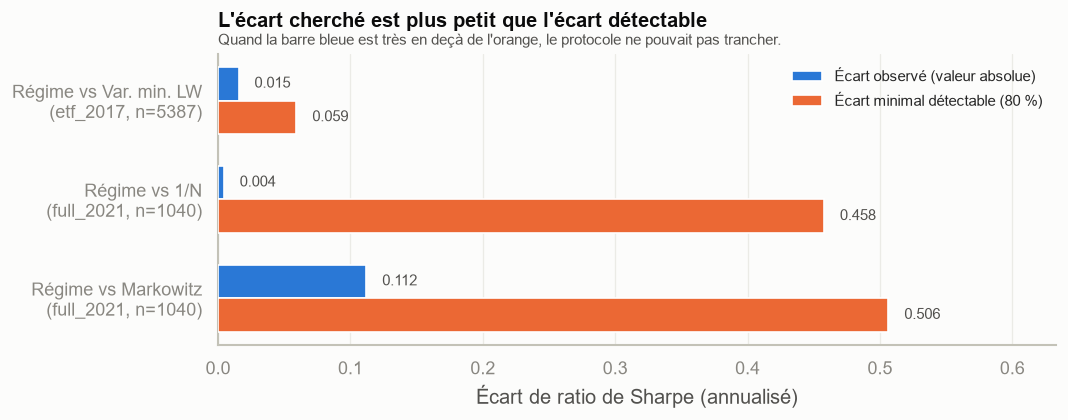

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.6))
y = np.arange(len(puissance))
hauteur = 0.34

# Deux séries -> légende obligatoire ; étiquettes directes en complément.
ax.barh(y + hauteur / 2, puissance["écart observé"].abs(), hauteur,
        color=SERIE_1, label="Écart observé (valeur absolue)", zorder=3)
ax.barh(y - hauteur / 2, puissance["EMD (80 %)"], hauteur,
        color=SERIE_2, label="Écart minimal détectable (80 %)", zorder=3)

for i, ligne in puissance.iterrows():
    ax.text(abs(ligne["écart observé"]) + 0.012, i + hauteur / 2,
            f"{abs(ligne['écart observé']):.3f}", va="center", fontsize=9, color=ENCRE_2)
    ax.text(ligne["EMD (80 %)"] + 0.012, i - hauteur / 2,
            f"{ligne['EMD (80 %)']:.3f}", va="center", fontsize=9, color=ENCRE_2)

ax.set_yticks(y)
ax.set_yticklabels([f"{r.comparaison}\n({r.univers}, n={r.n})" for r in puissance.itertuples()])
ax.set_xlabel("Écart de ratio de Sharpe (annualisé)")
ax.set_xlim(0, max(puissance["EMD (80 %)"]) * 1.25)
habiller(ax, "L'écart cherché est plus petit que l'écart détectable",
         "Quand la barre bleue est très en deçà de l'orange, le protocole ne pouvait pas trancher.")
# Haut-droite : la barre la plus courte est en haut, donc l'espace y est libre.
# En bas à droite la légende recouvrait l'étiquette de la barre la plus longue.
ax.legend(frameon=False, loc="upper right", fontsize=9)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

La lecture est directe : sur `full_2021`, l'écart observé est une fraction de
l'écart détectable. Le protocole aurait rendu le même verdict si l'effet avait
été trois fois plus grand.

La fenêtre utilisée ci-dessus est celle de `dashboard_equity.parquet`. La
comparaison publiée porte sur le **segment de test gelé**, plus court — donc
un EMD encore plus élevé. La cellule suivante projette l'erreur-type sur
d'autres tailles d'échantillon, à la racine de *n*.

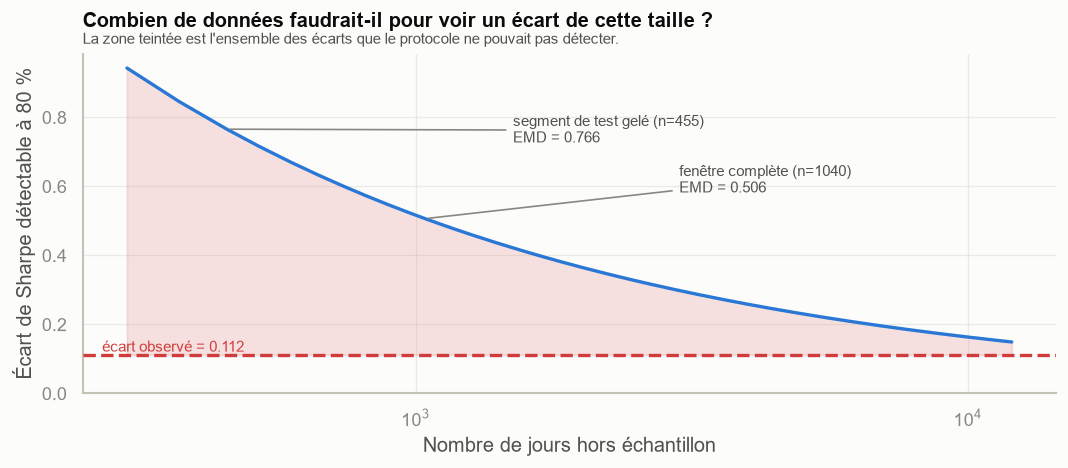

La courbe croise l'écart observé vers n ≈ 12,000 jours (48 ans de cotation).


In [4]:
ref = puissance.iloc[0]
n_obs, se_obs, observe = int(ref["n"]), ref["erreur-type"], abs(ref["écart observé"])

tailles = np.unique(np.concatenate([np.array([455]), np.linspace(300, 12000, 160).astype(int)]))
emd = np.array([
    sharpe_difference_mde(se_obs, alpha=0.10, power=0.80, n_observed=n_obs, n_target=int(t))
    for t in tailles
])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tailles, emd, color=SERIE_1, linewidth=2, zorder=3)
ax.axhline(observe, color=CRITIQUE, linewidth=2, linestyle="--", zorder=3)

# alpha 0.06 était invisible alors que le sous-titre y renvoie explicitement.
ax.fill_between(tailles, observe, emd, where=(emd >= observe),
                color=CRITIQUE, alpha=0.14, zorder=1)

# À gauche : à droite l'étiquette débordait du cadre, et une fois rentrée elle
# se faisait traverser par la courbe. À gauche la courbe est haute, l'espace
# au-dessus du seuil est libre.
ax.text(0.02, observe, f"écart observé = {observe:.3f}",
        transform=ax.get_yaxis_transform(), va="bottom", ha="left",
        fontsize=9, color=CRITIQUE)
ax.annotate(f"segment de test gelé (n=455)\nEMD = {emd[tailles == 455][0]:.3f}",
            xy=(455, emd[tailles == 455][0]), xytext=(1500, emd[tailles == 455][0] * 0.95),
            fontsize=9, color=ENCRE_2,
            arrowprops=dict(arrowstyle="-", color=ATTENUE, linewidth=1))
ax.annotate(f"fenêtre complète (n={n_obs})\nEMD = {ref['EMD (80 %)']:.3f}",
            xy=(n_obs, ref["EMD (80 %)"]), xytext=(3000, ref["EMD (80 %)"] * 1.15),
            fontsize=9, color=ENCRE_2,
            arrowprops=dict(arrowstyle="-", color=ATTENUE, linewidth=1))

ax.set_xlabel("Nombre de jours hors échantillon")
ax.set_ylabel("Écart de Sharpe détectable à 80 %")
ax.set_xscale("log")
ax.set_ylim(0, None)
habiller(ax, "Combien de données faudrait-il pour voir un écart de cette taille ?",
         "La zone teintée est l'ensemble des écarts que le protocole ne pouvait pas détecter.")
plt.tight_layout()
plt.show()

print(f"La courbe croise l'écart observé vers n ≈ "
      f"{int(tailles[np.argmin(np.abs(emd - observe))]):,} jours "
      f"({tailles[np.argmin(np.abs(emd - observe))] / 252:.0f} ans de cotation).")

## 2. La sélection : l'apprentissage prédit-il le hors-échantillon ?

La validation croisée combinatoire symétrique (Bailey, Borwein, López de Prado
& Zhu) découpe la matrice essais × temps, forme **toutes** les partitions
équilibrées, et compare le rang de la configuration gagnante en apprentissage
à son rang hors échantillon.

La pente de dégradation est le diagnostic le plus parlant : elle relie la
performance en apprentissage à la performance hors échantillon de la
configuration retenue.

In [5]:
resultats_pbo = {}
for nom in ("full_2021", "etf_2017"):
    large = univers(nom)
    candidats = {c: large[c] for c in large.columns if c not in BENCHMARKS}
    resultats_pbo[nom] = probability_of_backtest_overfitting(candidats, n_splits=10)

tableau_pbo = pd.DataFrame(resultats_pbo).T[
    ["pbo", "median_logit", "performance_degradation_slope",
     "probability_of_loss", "n_trials", "n_partitions"]
]
tableau_pbo.columns = ["PBO", "logit médian", "pente de dégradation",
                       "prob. de perte", "essais", "partitions"]
display(tableau_pbo.round(4))

,PBO,logit médian,pente de dégradation,prob. de perte,essais,partitions
full_2021,0.333333,0.756127,-1.082482,0.051587,240,252
etf_2017,0.714286,-0.482158,-0.993645,0.0,240,252


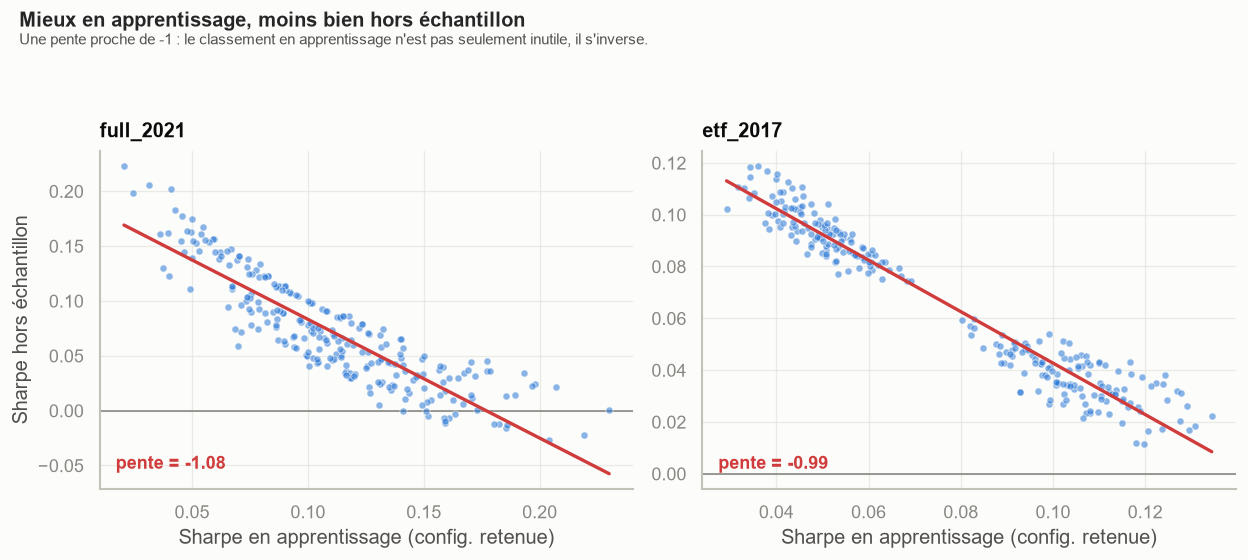

In [6]:
# Petits multiples : un panneau par univers, une seule série par panneau —
# préférable à deux couleurs sur un même axe.
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=False)

for ax, nom in zip(axes, ("full_2021", "etf_2017")):
    large = univers(nom)
    candidats = {c: large[c] for c in large.columns if c not in BENCHMARKS}
    noms = sorted(candidats)
    mat = np.column_stack([candidats[c].to_numpy() for c in noms])

    from itertools import combinations
    S, T = 10, mat.shape[0] // 10 * 10
    blocs = mat[:T].reshape(10, T // 10, mat.shape[1])
    somme, somme_carre = blocs.sum(axis=1), (blocs**2).sum(axis=1)

    xs, ys = [], []
    for combo in combinations(range(10), 5):
        masque = np.zeros(10); masque[list(combo)] = 1.0
        comp = 1.0 - masque
        def sharpe(m):
            cnt = (T // 10) * 5
            moy = (m @ somme) / cnt
            var = (m @ somme_carre) / cnt - moy**2
            return np.where(var > 0, moy / np.sqrt(np.maximum(var, 1e-300)), 0.0)
        app, hors = sharpe(masque), sharpe(comp)
        gagnant = int(np.argmax(app))
        xs.append(app[gagnant]); ys.append(hors[gagnant])

    xs, ys = np.array(xs), np.array(ys)
    pente, ordonnee = np.polyfit(xs, ys, 1)

    ax.axhline(0, color=ATTENUE, linewidth=1, zorder=2)
    ax.scatter(xs, ys, s=18, color=SERIE_1, alpha=0.55,
               edgecolor=FOND, linewidth=0.6, zorder=3)
    grille_x = np.linspace(xs.min(), xs.max(), 50)
    ax.plot(grille_x, pente * grille_x + ordonnee, color=CRITIQUE, linewidth=2, zorder=4)
    ax.text(0.03, 0.06, f"pente = {pente:+.2f}", transform=ax.transAxes,
            fontsize=11, fontweight="bold", color=CRITIQUE)
    ax.set_xlabel("Sharpe en apprentissage (config. retenue)")
    if ax is axes[0]:
        ax.set_ylabel("Sharpe hors échantillon")
    habiller(ax, nom)

fig.suptitle("Mieux en apprentissage, moins bien hors échantillon",
             fontsize=12, fontweight="bold", x=0.02, ha="left", y=1.10)
fig.text(0.02, 1.035, "Une pente proche de -1 : le classement en apprentissage "
                      "n'est pas seulement inutile, il s'inverse.",
         fontsize=9, color=ENCRE_2, ha="left")
plt.tight_layout(rect=(0, 0, 1, 0.99))
plt.show()

## 3. Ce que l'on peut désormais affirmer

Reality Check et SPA testent contre un comparateur unique : quand ils ne
rejettent pas, ils se taisent. Deux procédures complémentaires donnent une
sortie **positive**.

Le *Model Confidence Set* renvoie l'ensemble des stratégies que les données ne
permettent pas d'écarter. Le StepM de Romano & Wolf rend un verdict **par
stratégie** au lieu d'un p unique. Ce sont des dénombrements et des verdicts :
un tableau les sert mieux qu'un graphique.

Rappel de vocabulaire (AGENTS.md §5.2) : une stratégie conservée n'est pas
« équivalente » aux autres — les données ne permettent simplement pas de
l'écarter.

In [7]:
resume = []
for nom in ("full_2021", "etf_2017"):
    large = univers(nom)
    mcs = model_confidence_set({c: large[c] for c in large.columns}, size=0.10,
                               n_boot=2000, seed=0)
    candidats = {c: large[c] for c in large.columns if c not in BENCHMARKS}
    step = stepm_superior_models(candidats, large["equal_weight"], size=0.05,
                                 n_boot=2000, seed=0)
    resume.append({
        "univers": nom,
        "MCS : conservées": f"{mcs['n_included']} / {mcs['n_candidates']}",
        "1/N conservé ?": "oui" if "equal_weight" in mcs["included"] else "NON — écarté",
        "régime conservé ?": "oui" if "regime_conditional" in mcs["included"] else "NON — écarté",
        "StepM vs 1/N : nommées": f"{step['n_superior']} / {step['n_candidates']}",
    })

display(pd.DataFrame(resume).set_index("univers"))
display(Markdown(
    "Sur `etf_2017`, le comparateur naïf est **écarté** de l'ensemble : c'est une "
    "affirmation positive que le Reality Check, par construction, ne pouvait pas "
    "produire."
))

,MCS : conservées,1/N conservé ?,régime conservé ?,StepM vs 1/N : nommées
univers,,,,
full_2021,237 / 242,oui,oui,0 / 240
etf_2017,237 / 242,NON — écarté,oui,0 / 240


Sur `etf_2017`, le comparateur naïf est **écarté** de l'ensemble : c'est une affirmation positive que le Reality Check, par construction, ne pouvait pas produire.

## 4. Contrôle de l'implémentation

Avant d'ajouter des instruments, il fallait vérifier celui qui était déjà là.
Le Reality Check du projet est écrit à la main ; `arch` implémente la même
procédure. Les deux sont comparés sur les séries publiées de
`reality_check_results.json`.

In [8]:
from arch.bootstrap import SPA

controle = []
for nom in ("full_2021", "etf_2017"):
    large = univers(nom)
    cols = [c for c in large.columns if c not in BENCHMARKS]
    for comparateur in BENCHMARKS:
        spa = SPA(-large[comparateur].to_numpy(), -large[cols].to_numpy(),
                  block_size=21, reps=2000, bootstrap="circular", seed=0)
        spa.compute()
        publie = reality["universes"][nom]["tests"][f"{comparateur}__mean_return"]
        controle.append({
            "univers": nom,
            "comparateur": comparateur,
            "RC publié": publie["reality_check_p_value"],
            "RC arch": float(spa.pvalues["upper"]),
            "écart": abs(publie["reality_check_p_value"] - float(spa.pvalues["upper"])),
        })

controle = pd.DataFrame(controle)
display(controle.round(4))
print(f"écart maximal sur les quatre comparaisons : {controle['écart'].max():.4f}")

,univers,comparateur,RC publié,RC arch,écart
0,full_2021,regime_conditional,0.1239,0.1235,0.0004
1,full_2021,equal_weight,0.0915,0.0910,0.0005
2,etf_2017,regime_conditional,0.2259,0.2255,0.0004
3,etf_2017,equal_weight,0.0630,0.0625,0.0005


écart maximal sur les quatre comparaisons : 0.0005


## Synthèse

| Constat | Conséquence pour la lecture des résultats |
|---|---|
| L'EMD dépasse largement l'écart observé | « Non établi » décrit la taille de l'échantillon, pas les modèles. |
| Pente de dégradation proche de $-1$ | Le maximum d'une recherche à 240 configurations est un artefact de sélection. |
| 1/N écarté du MCS sur `etf_2017` | Une affirmation positive, là où RC et SPA ne pouvaient que se taire. |
| Reality Check reproduit par `arch` | L'implémentation maison est correcte. |

Rien ici ne renverse une conclusion du mémoire : le système à régimes reste
derrière son comparateur, et aucune surperformance n'est établie. Ce qui
change est la **raison** pour laquelle elle ne l'est pas — et c'est une
propriété du protocole, connaissable à l'avance.